# SRQ4 — ViT Baseline Comparison

Trains EfficientFormer-L1 under the same two-phase transfer learning protocol used for all CNN experiments.
All hyperparameters are loaded from the CNN baseline grid search — identical protocol, no separate ViT tuning.
This is a deliberate methodological choice: the comparison tests architectural paradigm under shared constraints,
not per-architecture optimisation.

**Protocol:**
- Phase 1 `param_mode='head'`: transformer encoder frozen, only classifier head warms up
- Phase 2 `param_mode='all'`: full fine-tuning with gradient clipping (max_norm=1.0)
- Phase 2 patience increased to 5 (vs 3 for CNNs) — ViTs stabilise slower after unfreezing
- All hyperparameters loaded from `grid-search-results/optimal_config.csv` (same as CNN baseline)
- 5-fold stratified CV; best fold selected by val F1 for test evaluation
- **Section 6:** Final held-out test set evaluation — run once only after all CV decisions are made


## 1 · Paths & Imports

In [20]:
import sys
from pathlib import Path

ABSOLUTE_PATH = Path().resolve()
PROJECT_ROOT  = ABSOLUTE_PATH.parents[1]
DATA_DIR      = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR   = PROJECT_ROOT / "data" / "experiments" / "vit-comparison-results"
WEIGHTS_DIR   = RESULTS_DIR / "weights"
CURVES_DIR    = RESULTS_DIR / "training-curves"
PLOTS_DIR     = RESULTS_DIR / "plots"

# Upstream experiment directories (read-only)
ARCH_EVAL_RESULTS_DIR     = PROJECT_ROOT / "data" / "experiments" / "arch-eval-results"
HEAD_ABLATION_RESULTS_DIR = PROJECT_ROOT / "data" / "experiments" / "head-ablation-results"
GRID_SEARCH_RESULTS_DIR   = PROJECT_ROOT / "data" / "experiments" / "grid-search-results"

for d in [RESULTS_DIR, WEIGHTS_DIR, CURVES_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

sys.path.append(str(PROJECT_ROOT))

print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir     : {DATA_DIR}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"Weights dir  : {WEIGHTS_DIR}")

Project root : C:\Users\markm\Workspace\ms-machine-learning-diagnosis
Data dir     : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
Results dir  : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\vit-comparison-results
Weights dir  : C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\vit-comparison-results\weights


In [21]:
import csv
import time
import traceback
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.metrics import f1_score

import src.scripts.data      as data
import src.scripts.models    as models
import src.scripts.trainer   as trainer
import src.scripts.utils     as utils
import src.scripts.evaluator as evaluator

utils.set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Random seed set to 42 for Python, NumPy, and PyTorch
Device: cpu


## 2 · Data — Outer Split (Identical to All Other Experiments)

Fixed seed 42 outer 80/20 stratified split. All training and model selection operates within `X_trainval`.
The held-out test set is set aside until final evaluation in Section 8.

In [22]:
path, categories = data.get_dataset(str(DATA_DIR))
classes = data.get_classes(path, categories, visualise=False)

image_paths, labels = data.get_paths_and_labels(path, classes)
train_transform, test_transform = data.get_transforms()

X_trainval, y_trainval, X_test, y_test = data.get_trainval_test_split(
    image_paths, labels,
    test_split=0.20,
    SEED=42
)

print(f"\nSRQ4 operates on {len(X_trainval)} train+val samples.")
print("Held-out test set is NOT used until Section 8 (final evaluation).")

get_dataset()>>> Dataset already exists in C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\raw
get_dataset()>>> Available categories: ['Control Axial_crop', 'Control Saggital_crop', 'MS Axial_crop', 'MS Saggital_crop']
get_paths_and_labels()>>> Total images: 1652
get_trainval_test_split()>>> Train+Val pool : 1321 (80.0%)
get_trainval_test_split()>>> Held-out test  : 331 (20.0%)
get_trainval_test_split()>>> TrainVal class ratio — MS: 520  Non-MS: 801
get_trainval_test_split()>>> Test     class ratio — MS: 130  Non-MS: 201

SRQ4 operates on 1321 train+val samples.
Held-out test set is NOT used until Section 8 (final evaluation).


## 3 · Configuration

All hyperparameters loaded from `grid-search-results/optimal_config.csv` — identical to the CNN baseline.
Phase 1 parameters are fixed a priori (same as all CNN experiments).
Phase 2 LR and weight decay are the CNN-optimal values from the grid search.
Phase 2 patience is increased from 3 to 5 to allow ViT stabilisation after unfreezing.
Gradient clipping (max_norm=1.0) is applied in Phase 2 — standard practice for ViT fine-tuning.


In [23]:
# ── Load hyperparameters from CNN baseline grid search ───────────────────────
OPTIMAL_CONFIG_FILE = GRID_SEARCH_RESULTS_DIR / "optimal_config.csv"
if not OPTIMAL_CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"optimal_config.csv not found at {OPTIMAL_CONFIG_FILE}\n"
        "Run the grid search notebook first."
    )

optimal = pd.read_csv(OPTIMAL_CONFIG_FILE).iloc[0]
LR_PHASE1         = float(optimal["lr_phase1"])
WD_PHASE1         = float(optimal["wd_phase1"])
BEST_LR_PHASE2    = float(optimal["lr_phase2"])
BEST_WEIGHT_DECAY = float(optimal["weight_decay"])

# ── Fixed protocol parameters ─────────────────────────────────────────────────
SEED           = 42
BATCH_SIZE     = 32
WINNING_HEAD   = "linear"
P1_EPOCHS      = 20
P1_PATIENCE    = 4
P2_EPOCHS      = 15
P2_PATIENCE    = 5       # increased from 3: ViTs stabilise slower than ResNets
GRAD_CLIP_NORM = 1.0     # standard for ViT fine-tuning; no-op for Phase 1
ARCHITECTURE   = "efficientformer"

print(f"Loaded from : {OPTIMAL_CONFIG_FILE.name}")
print(f"  lr_phase1    = {LR_PHASE1:.0e}")
print(f"  wd_phase1    = {WD_PHASE1}")
print(f"  lr_phase2    = {BEST_LR_PHASE2:.0e}")
print(f"  weight_decay = {BEST_WEIGHT_DECAY:.0e}")
print(f"")
print(f"Architecture : {ARCHITECTURE}")
print(f"Head         : {WINNING_HEAD}")
print(f"Phase 1      : epochs={P1_EPOCHS}  patience={P1_PATIENCE}")
print(f"Phase 2      : epochs={P2_EPOCHS}  patience={P2_PATIENCE}  grad_clip={GRAD_CLIP_NORM}")
print(f"Note         : Phase 2 hyperparameters are CNN-optimal values — same protocol, no separate ViT tuning")


Loaded from : optimal_config.csv
  lr_phase1    = 1e-03
  wd_phase1    = 0.0
  lr_phase2    = 1e-04
  weight_decay = 1e-04

Architecture : efficientformer
Head         : linear
Phase 1      : epochs=20  patience=4
Phase 2      : epochs=15  patience=5  grad_clip=1.0
Note         : Phase 2 hyperparameters are CNN-optimal values — same protocol, no separate ViT tuning


## 4 · 5-Fold CV Training — EfficientFormer

Trains EfficientFormer under the CNN-optimal config using 5-fold stratified CV.
Weights saved per fold. Results saved fold-by-fold; safe to interrupt and resume.


In [24]:
N_SPLITS     = 5
RESULTS_FILE = RESULTS_DIR / "vit_cv_results.csv"
CV_FIELDNAMES = [
    "architecture", "lr_phase1", "wd_phase1", "lr_phase2", "weight_decay",
    "fold", "val_acc", "val_loss", "val_f1",
    "p1_epochs_run", "p2_epochs_run",
    "weights_path", "timestamp", "error"
]

total_cv_runs = N_SPLITS
print(f"EfficientFormer × {N_SPLITS} folds = {total_cv_runs} runs")
print(f"lr_phase2 : {BEST_LR_PHASE2:.0e}  weight_decay : {BEST_WEIGHT_DECAY:.0e}")
print(f"Results   → {RESULTS_FILE}")
print(f"Weights   → {WEIGHTS_DIR}/{ARCHITECTURE}/fold_<n>.pt")

EfficientFormer × 5 folds = 5 runs
lr_phase2 : 1e-04  weight_decay : 1e-04
Results   → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\vit-comparison-results\vit_cv_results.csv
Weights   → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\vit-comparison-results\weights/efficientformer/fold_<n>.pt


In [25]:
completed_cv = utils.load_completed_runs(
    RESULTS_FILE,
    [("architecture", str), ("fold", int)]
)
cv_run_number = len(completed_cv)
print(f"Device: {DEVICE}")
print(f"{N_SPLITS} folds — {cv_run_number} already completed\n")

for fold_idx in range(N_SPLITS):

    run_key = (ARCHITECTURE, fold_idx)
    if run_key in completed_cv:
        print(f"SKIP  fold={fold_idx+1}/{N_SPLITS}")
        continue

    utils.set_seed(SEED)
    cv_run_number += 1
    print(f"\n{'='*65}")
    print(f"  Run {cv_run_number}/{total_cv_runs}  |  fold={fold_idx+1}/{N_SPLITS}")
    print(f"{'='*65}")

    error_msg = ""
    val_f1 = val_acc = val_loss = float("nan")
    p1_epochs_run = p2_epochs_run = 0
    wpath = utils.weights_path_for(WEIGHTS_DIR, ARCHITECTURE, fold_idx)

    try:
        train_loader, val_loader = data.get_fold_loaders(
            X_trainval, y_trainval,
            fold_idx=fold_idx,
            train_transform=train_transform,
            test_transform=test_transform,
            n_splits=N_SPLITS,
            batch_size=BATCH_SIZE,
            SEED=SEED
        )

        model = models.get_model(architecture=ARCHITECTURE, head=WINNING_HEAD)

        run_configs = {
            "phase1": {
                "num_epochs"  : P1_EPOCHS,
                "lr"          : LR_PHASE1,
                "parameters"  : "head",
                "optimiser"   : optim.AdamW,
                "criterion"   : nn.BCEWithLogitsLoss(),
                "weight_decay": WD_PHASE1,
            },
            "phase2": {
                "num_epochs"  : P2_EPOCHS,
                "lr"          : BEST_LR_PHASE2,
                "parameters"  : "all",
                "optimiser"   : optim.AdamW,
                "criterion"   : nn.BCEWithLogitsLoss(),
                "weight_decay": BEST_WEIGHT_DECAY,
            },
        }

        # Phase 1
        losses_p1, accs_p1, val_losses_p1, val_accs_p1 = trainer.train_model(
            model, train_loader, val_loader,
            config_name="phase1",
            train_configs=run_configs,
            early_stopping_patience=P1_PATIENCE
        )
        p1_epochs_run = len(val_accs_p1)

        utils.plot(
            losses_p1, accs_p1,
            config_name=f"phase1_fold{fold_idx}",
            val_losses=val_losses_p1, val_accuracies=val_accs_p1,
            model_name=ARCHITECTURE,
            save_dir=str(CURVES_DIR),
            show=False
        )

        # Phase 2 with gradient clipping
        losses_p2, accs_p2, val_losses_p2, val_accs_p2 = trainer.train_model(
            model, train_loader, val_loader,
            config_name="phase2",
            train_configs=run_configs,
            early_stopping_patience=P2_PATIENCE,
            grad_clip_norm=GRAD_CLIP_NORM
        )
        p2_epochs_run = len(val_accs_p2)

        utils.plot(
            losses_p2, accs_p2,
            config_name=f"phase2_fold{fold_idx}",
            val_losses=val_losses_p2, val_accuracies=val_accs_p2,
            model_name=ARCHITECTURE,
            save_dir=str(CURVES_DIR),
            show=False
        )

        val_loss = val_losses_p2[-1]
        val_acc  = val_accs_p2[-1]

        # Val F1
        model.eval()
        y_true_val, y_pred_val = [], []
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs = imgs.to(DEVICE)
                probs = torch.sigmoid(model(imgs)).cpu().numpy().flatten()
                preds = (probs >= 0.5).astype(int)
                y_true_val.extend(lbls.numpy().astype(int))
                y_pred_val.extend(preds)
        val_f1 = f1_score(y_true_val, y_pred_val)

        utils.save_weights(model, wpath)
        print(f"  val_f1={val_f1:.4f}  val_acc={val_acc:.4f}  val_loss={val_loss:.4f}  "
              f"(p1={p1_epochs_run}ep  p2={p2_epochs_run}ep)")
        print(f"  Weights → {wpath}")

    except Exception as e:
        error_msg = str(e)
        print(f"  ERROR: {error_msg}")
        traceback.print_exc()

    utils.append_result(RESULTS_FILE, CV_FIELDNAMES, {
        "architecture" : ARCHITECTURE,
        "lr_phase1"    : LR_PHASE1,
        "wd_phase1"    : WD_PHASE1,
        "lr_phase2"    : BEST_LR_PHASE2,
        "weight_decay" : BEST_WEIGHT_DECAY,
        "fold"         : fold_idx,
        "val_acc"      : round(val_acc, 4) if not np.isnan(val_acc) else "",
        "val_loss"     : round(val_loss, 4) if not np.isnan(val_loss) else "",
        "val_f1"       : round(val_f1, 4) if not np.isnan(val_f1) else "",
        "p1_epochs_run": p1_epochs_run,
        "p2_epochs_run": p2_epochs_run,
        "weights_path" : str(wpath),
        "timestamp"    : datetime.now().isoformat(timespec="seconds"),
        "error"        : error_msg,
    })

print(f"\n{'='*65}")
print("CV TRAINING COMPLETE")
print(f"Results → {RESULTS_FILE}")

Device: cpu
5 folds — 5 already completed

SKIP  fold=1/5
SKIP  fold=2/5
SKIP  fold=3/5
SKIP  fold=4/5
SKIP  fold=5/5

CV TRAINING COMPLETE
Results → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\vit-comparison-results\vit_cv_results.csv


## 5 · CV Results Summary


In [26]:
df_cv = pd.read_csv(RESULTS_FILE)
df_cv["error"] = df_cv["error"].fillna("")
df_ok   = df_cv[df_cv["error"] == ""].copy()
df_fail = df_cv[df_cv["error"] != ""].copy()

for col in ["val_f1", "val_acc", "val_loss"]:
    df_ok[col] = df_ok[col].astype(float)

print(f"Successful runs : {len(df_ok)} / {total_cv_runs}")
print(f"Failed runs     : {len(df_fail)}")
if len(df_fail):
    print(df_fail[["fold", "error"]].to_string(index=False))

Successful runs : 5 / 5
Failed runs     : 0


In [27]:
# ── CV comparison vs cbam_block_post ─────────────────────────────────────────────────
arch_eval_csv = ARCH_EVAL_RESULTS_DIR / "arch_eval_results.csv"
CNN_ARCH      = "cbam_block_post"

if arch_eval_csv.exists():
    df_arch = pd.read_csv(arch_eval_csv)
    df_arch["error"] = df_arch["error"].fillna("")
    df_arch = df_arch[(df_arch["error"] == "") & (df_arch["architecture"] == CNN_ARCH)]

    if df_arch.empty:
        print(f"No successful {CNN_ARCH} runs found — comparison skipped")
    else:
        cbam_mean = df_arch["val_f1"].mean()
        print(f"\n  {CNN_ARCH} CV mean F1  : {cbam_mean:.4f}")
        print(f"  ViT CV mean F1      : {df_ok.val_f1.mean():.4f}")
        print(f"  \u0394 (ViT \u2212 {CNN_ARCH})  : {df_ok.val_f1.mean() - cbam_mean:+.4f}")
else:
    print("arch-eval results not found — comparison skipped")



  cbam_block_post CV mean F1  : 0.8991
  ViT CV mean F1      : 0.8848
  Δ (ViT − cbam_block_post)  : -0.0143


In [28]:
# ── Fold selection — best val F1 ──────────────────────────────────────────────
if not df_ok.empty:
    best_fold_row = df_ok.sort_values("val_f1", ascending=False).iloc[0]
    SELECTED_FOLD = int(best_fold_row["fold"])
    print(f"Selected fold {SELECTED_FOLD+1}  "
          f"(val_f1={best_fold_row.val_f1:.4f}  val_loss={best_fold_row.val_loss:.4f})")

Selected fold 3  (val_f1=0.9442  val_loss=0.2380)


## 6 · Final Test Set Evaluation — SRQ4

Loads the best fold weights for EfficientFormer and the best CNN from arch-eval.
Both evaluated once on the held-out test set. Run once only after all model selection decisions are made.


In [29]:
test_loader = data.get_test_loader(X_test, y_test, test_transform, batch_size=BATCH_SIZE)
print(f"Device: {DEVICE}")

get_test_loader()>>> Test loader ready — 331 samples
Device: cpu


In [30]:
test_results = {}

# ── Evaluate EfficientFormer ──────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  Test evaluation: {ARCHITECTURE}  (fold {SELECTED_FOLD+1})")
print(f"{'='*60}")

vit_weights = utils.weights_path_for(WEIGHTS_DIR, ARCHITECTURE, SELECTED_FOLD)

if not vit_weights.exists():
    print(f"  SKIP — weights not found at {vit_weights}")
else:
    utils.set_seed(SEED)
    vit_model = models.get_model(architecture=ARCHITECTURE, head=WINNING_HEAD)
    vit_model = utils.load_weights(vit_model, vit_weights, device=DEVICE)

    acc, prec, rec, f1, auc, ece, conf, report = evaluator.evaluate_model(
        model=vit_model, test_loader=test_loader, device=DEVICE
    )
    test_results[ARCHITECTURE] = {
        "test_f1": round(f1, 4), "test_auc": round(auc, 4),
        "test_ece": round(ece, 4), "test_acc": round(acc, 4),
        "test_prec": round(prec, 4), "test_rec": round(rec, 4),
        "conf_matrix": conf.tolist(),
        "lr_phase2": BEST_LR_PHASE2, "weight_decay": BEST_WEIGHT_DECAY,
    }


  Test evaluation: efficientformer  (fold 3)
Random seed set to 42 for Python, NumPy, and PyTorch


get_model()>>> architecture='efficientformer'  head='linear'
load_weights()>>> Model loaded successfully and set to evaluation mode.
Accuracy  : 0.9517
Precision : 0.9914
Recall    : 0.8846
F1        : 0.9350
AUC-ROC   : 0.9864
ECE       : 0.0474  (lower = better calibrated; 0 = perfect)
Confusion Matrix:
 [[200   1]
 [ 15 115]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96       201
           1       0.99      0.88      0.93       130

    accuracy                           0.95       331
   macro avg       0.96      0.94      0.95       331
weighted avg       0.95      0.95      0.95       331



In [31]:
# ── Evaluate best cbam_block_post fold from arch-eval ───────────────────────────────
CNN_ARCH      = "cbam_block_post"
arch_eval_csv = ARCH_EVAL_RESULTS_DIR / "arch_eval_results.csv"

if arch_eval_csv.exists():
    df_arch = pd.read_csv(arch_eval_csv)
    df_arch["error"] = df_arch["error"].fillna("")
    df_arch = df_arch[(df_arch["error"] == "") & (df_arch["architecture"] == CNN_ARCH)]

    if df_arch.empty:
        print(f"No successful {CNN_ARCH} runs found — CNN comparison skipped")
    else:
        cnn_best_fold = int(
            df_arch.sort_values("val_f1", ascending=False).iloc[0]["fold"]
        )
        cnn_weights = ARCH_EVAL_RESULTS_DIR / "weights" / CNN_ARCH / f"fold_{cnn_best_fold}.pt"

        print(f"\n{'='*60}")
        print(f"  Test evaluation: {CNN_ARCH}  (best fold = {cnn_best_fold+1})")
        print(f"{'='*60}")

        if not cnn_weights.exists():
            print(f"  SKIP — weights not found at {cnn_weights}")
        else:
            utils.set_seed(SEED)
            cnn_model = models.get_model(architecture=CNN_ARCH, head=WINNING_HEAD)
            cnn_model = utils.load_weights(cnn_model, cnn_weights, device=DEVICE)

            acc, prec, rec, f1, auc, ece, conf, report = evaluator.evaluate_model(
                model=cnn_model, test_loader=test_loader, device=DEVICE
            )
            test_results[CNN_ARCH] = {
                "test_f1"  : round(f1,   4), "test_auc" : round(auc, 4),
                "test_ece" : round(ece,  4), "test_acc" : round(acc, 4),
                "test_prec": round(prec, 4), "test_rec" : round(rec, 4),
                "conf_matrix": conf.tolist(),
            }
else:
    print("arch-eval results not found — CNN comparison skipped")



  Test evaluation: cbam_block_post  (best fold = 1)
Random seed set to 42 for Python, NumPy, and PyTorch
get_model()>>> architecture='cbam_block_post'  head='linear'
load_weights()>>> Model loaded successfully and set to evaluation mode.
Accuracy  : 0.9547
Precision : 0.9675
Recall    : 0.9154
F1        : 0.9407
AUC-ROC   : 0.9883
ECE       : 0.0369  (lower = better calibrated; 0 = perfect)
Confusion Matrix:
 [[197   4]
 [ 11 119]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96       201
           1       0.97      0.92      0.94       130

    accuracy                           0.95       331
   macro avg       0.96      0.95      0.95       331
weighted avg       0.96      0.95      0.95       331



In [32]:
# ── SRQ4 comparison table ─────────────────────────────────────────────────────
df_test = pd.DataFrame(test_results).T
df_test = df_test.drop(columns=["conf_matrix"])
for col in ["test_f1", "test_auc", "test_ece", "test_acc", "test_prec", "test_rec"]:
    df_test[col] = df_test[col].astype(float)

print("SRQ4 — Final Test Results\n")
print(f"{'Model':<30} {'F1':>8} {'AUC-ROC':>9} {'ECE':>8}")
print("-" * 58)
for arch, row in df_test.iterrows():
    print(f"  {arch:<28} {row.test_f1:>8.4f} {row.test_auc:>9.4f} {row.test_ece:>8.4f}")

# Delta (ViT − cbam_end)
if ARCHITECTURE in df_test.index and CNN_ARCH in df_test.index:
    delta_f1  = df_test.loc[ARCHITECTURE, "test_f1"]  - df_test.loc[CNN_ARCH, "test_f1"]
    delta_auc = df_test.loc[ARCHITECTURE, "test_auc"] - df_test.loc[CNN_ARCH, "test_auc"]
    delta_ece = df_test.loc[ARCHITECTURE, "test_ece"] - df_test.loc[CNN_ARCH, "test_ece"]
    print(f"\n  \u0394 ({ARCHITECTURE} \u2212 {CNN_ARCH}):")
    print(f"    \u0394F1      = {delta_f1:+.4f}")
    print(f"    \u0394AUC-ROC = {delta_auc:+.4f}")
    print(f"    \u0394ECE     = {delta_ece:+.4f}  (negative = better calibrated)")


SRQ4 — Final Test Results

Model                                F1   AUC-ROC      ECE
----------------------------------------------------------
  efficientformer                0.9350    0.9864   0.0474
  cbam_block_post                0.9407    0.9883   0.0369

  Δ (efficientformer − cbam_block_post):
    ΔF1      = -0.0057
    ΔAUC-ROC = -0.0019
    ΔECE     = +0.0105  (negative = better calibrated)


In [33]:
# ── Save test results ─────────────────────────────────────────────────────────
TEST_RESULTS_FILE = RESULTS_DIR / "srq4_test_results.csv"
df_test.to_csv(TEST_RESULTS_FILE)
print(f"Test results saved → {TEST_RESULTS_FILE}")

Test results saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\vit-comparison-results\srq4_test_results.csv


save_fig()>>> Saved → C:\Users\markm\Workspace\ms-machine-learning-diagnosis\data\experiments\vit-comparison-results\plots\srq4_test_results.svg


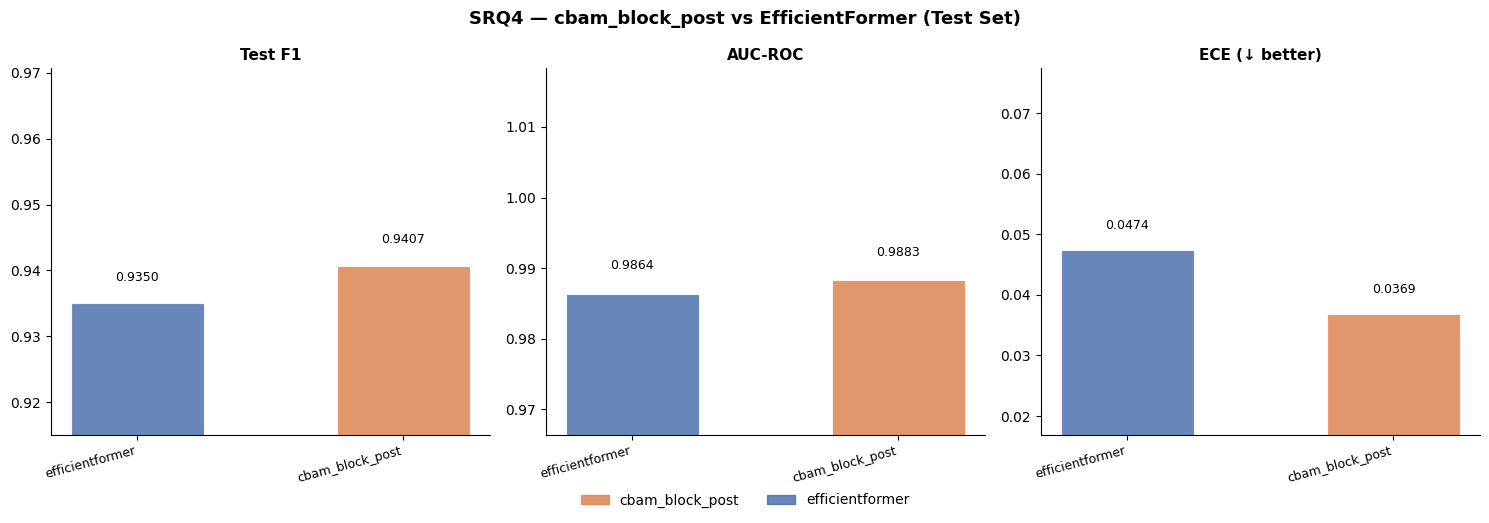

In [34]:
# ── Visualisation — F1, AUC-ROC, ECE ─────────────────────────────────────────
if not df_test.empty:
    COLOUR_MAP = {
        ARCHITECTURE: "#4C72B0",   # blue  — ViT
        CNN_ARCH:     "#DD8452",   # amber — CNN
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f"SRQ4 — {CNN_ARCH} vs EfficientFormer (Test Set)",
        fontsize=13, fontweight="bold"
    )

    models_ordered = list(df_test.index)
    colours = [COLOUR_MAP.get(a, "#888888") for a in models_ordered]
    x = np.arange(len(models_ordered))
    w = 0.5

    metrics = [
        ("test_f1",  "Test F1",        axes[0]),
        ("test_auc", "AUC-ROC",        axes[1]),
        ("test_ece", "ECE (\u2193 better)", axes[2]),
    ]

    for col, title, ax in metrics:
        vals = df_test.loc[models_ordered, col].values.astype(float)
        ax.bar(x, vals, width=w, color=colours, alpha=0.85, edgecolor="white", linewidth=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels(models_ordered, rotation=15, ha="right", fontsize=9)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)
        rng = vals.max() - vals.min()
        pad = max(rng * 0.3, 0.02)
        ax.set_ylim(max(0, vals.min() - pad), min(1.05, vals.max() + pad * 1.5))
        for xi, v in zip(x, vals):
            ax.text(xi, v + pad * 0.15, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

    # shared legend
    handles = [
        plt.Rectangle((0, 0), 1, 1, color="#DD8452", alpha=0.85, label=CNN_ARCH),
        plt.Rectangle((0, 0), 1, 1, color="#4C72B0", alpha=0.85, label=ARCHITECTURE),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=10,
               bbox_to_anchor=(0.5, -0.04), frameon=False)

    plt.tight_layout()
    utils.save_fig(fig, PLOTS_DIR, "srq4_test_results", formats=("svg",))
    plt.show()
